Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing All Libraries needed for Code

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

Loading Cleaned Dataset for Clustering

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Airbnb_Section_C/airbnb_cleaned.csv')
print(df.shape)
df.head()

(48645, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,log_price,has_reviews
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,5.010635,1
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,5.420535,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365,5.017280,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,4.499810,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,4.394449,1


Select & Prepare Features for Clustering

In [4]:
features = ['log_price', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'availability_365',
            'calculated_host_listings_count', 'neighbourhood_group', 'room_type']

df_cluster = df[features].copy()

le = LabelEncoder()
df_cluster['neighbourhood_group'] = le.fit_transform(df_cluster['neighbourhood_group'])
df_cluster['room_type'] = le.fit_transform(df_cluster['room_type'])

print(df_cluster.shape)
df_cluster.head()

(48645, 8)


,log_price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,calculated_host_listings_count,neighbourhood_group,room_type
0,5.010635,1,9,0.21,365,6,1,1
1,5.420535,1,45,0.38,355,2,2,0
2,5.017280,3,0,0.00,365,1,2,1
3,4.499810,1,270,4.64,194,1,1,0
4,4.394449,10,9,0.10,0,1,2,0


Features Scaling

In [5]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
print("Scaling done. Shape:", df_scaled.shape)

Scaling done. Shape: (48645, 8)


Finding Optimal K (Elbow Method)

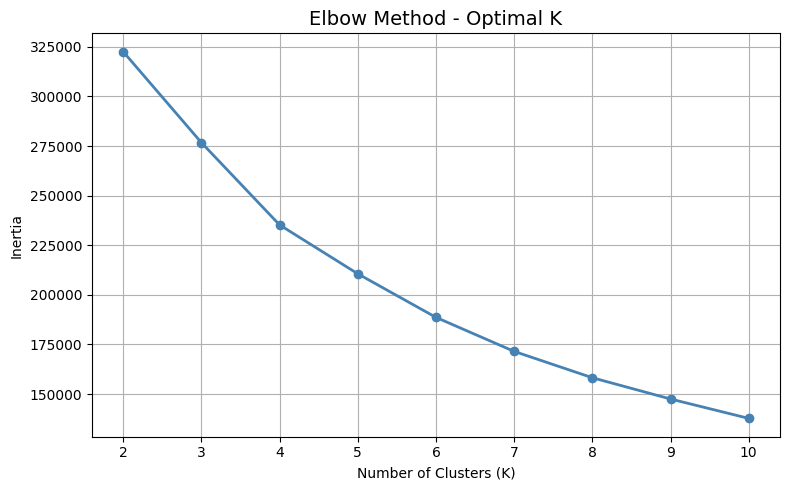

In [6]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Airbnb_Section_C/elbow_plot.png', dpi=150)
plt.show()

Silhouette Score

K=2 → Silhouette Score: 0.2293
K=3 → Silhouette Score: 0.2463
K=4 → Silhouette Score: 0.2623
K=5 → Silhouette Score: 0.2652
K=6 → Silhouette Score: 0.2551
K=7 → Silhouette Score: 0.2635
K=8 → Silhouette Score: 0.2590
K=9 → Silhouette Score: 0.2653
K=10 → Silhouette Score: 0.2581


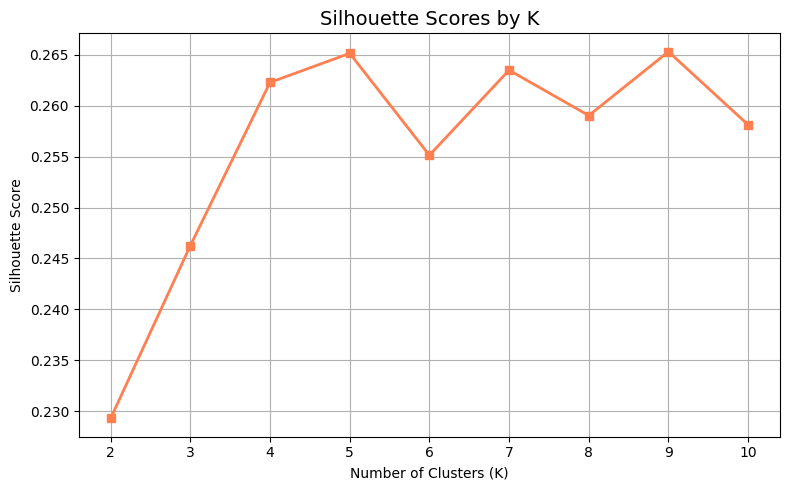

In [7]:
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    sil_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='s', color='coral', linewidth=2)
plt.title('Silhouette Scores by K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Airbnb_Section_C/silhouette_plot.png', dpi=150)
plt.show()

Final K-Means with Best K

In [8]:
best_k = 4  # Change this after seeing your plots

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(df_scaled)

print("Cluster distribution:")
print(df['cluster'].value_counts())

Cluster distribution:
cluster
1    21839
2    19777
0     6465
3      564
Name: count, dtype: int64


Profile the Clusters

In [9]:
# Numeric summary per cluster
profile = df.groupby('cluster')[['price', 'minimum_nights', 'number_of_reviews',
                                   'reviews_per_month', 'availability_365']].mean().round(2)
print(profile)

# Room type distribution per cluster
print(pd.crosstab(df['cluster'], df['room_type'], normalize='index').round(2))

# Neighbourhood distribution per cluster
print(pd.crosstab(df['cluster'], df['neighbourhood_group'], normalize='index').round(2))

          price  minimum_nights  number_of_reviews  reviews_per_month  \
cluster                                                                 
0        121.08            2.58             105.91               4.03   
1        203.41            8.91              10.89               0.63   
2         75.60            5.60              10.73               0.66   
3        273.04           30.27               2.37               0.72   

         availability_365  
cluster                    
0                  169.98  
1                   98.92  
2                  103.74  
3                  281.66  
room_type  Entire home/apt  Private room  Shared room
cluster                                              
0                     0.51          0.48         0.01
1                     0.98          0.02         0.00
2                     0.00          0.94         0.05
3                     0.98          0.02         0.00
neighbourhood_group  Bronx  Brooklyn  Manhattan  Queens  Staten Islan

Visualizations
Bar chart — Average Price per Cluster:

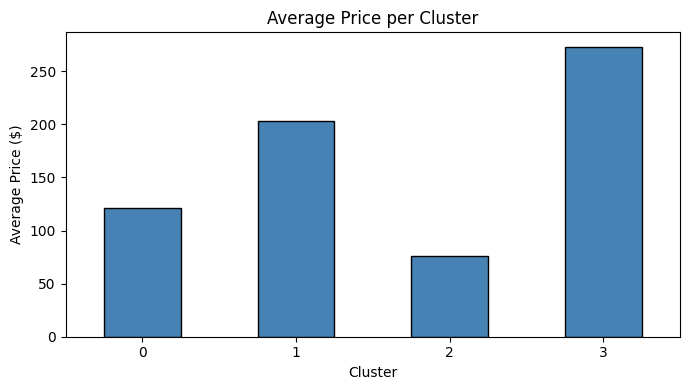

In [10]:
plt.figure(figsize=(7, 4))
df.groupby('cluster')['price'].mean().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Price per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Airbnb_Section_C/price_per_cluster.png', dpi=150)
plt.show()

Room type distribution per cluster:

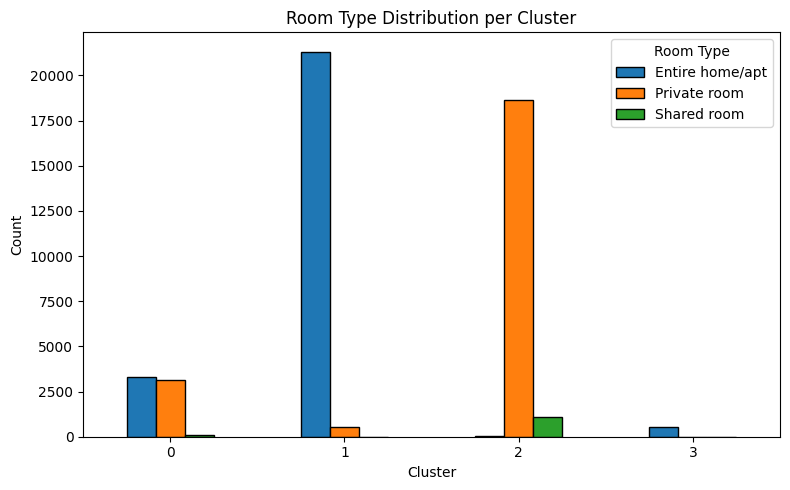

In [11]:
room_ct = pd.crosstab(df['cluster'], df['room_type'])
room_ct.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Room Type Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Room Type')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Airbnb_Section_C/roomtype_per_cluster.png', dpi=150)
plt.show()

Neighbourhood distribution per cluster:

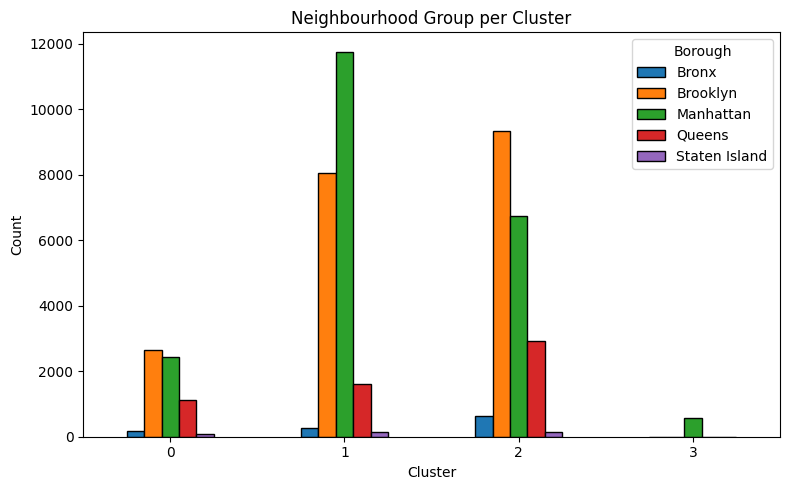

In [12]:
neigh_ct = pd.crosstab(df['cluster'], df['neighbourhood_group'])
neigh_ct.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Neighbourhood Group per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Borough')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Airbnb_Section_C/neighbourhood_per_cluster.png', dpi=150)
plt.show()

Final Output

In [13]:
df.to_csv('/content/drive/MyDrive/Airbnb_Section_C/airbnb_with_clusters.csv', index=False)
print("Done! File saved to your Drive.")

Done! File saved to your Drive.
